# BipedalWalker：MAC vs DR 综合目标验证损失

仅展示本次 MAC 和 DR 各五个 seed（0–4）的均值及 ±1 样本标准差阴影，不显示图例。**蓝色：DR；橙色：MAC**。横轴为实际 WM 更新次数，排除 MAC 前 10 轮 warmup；损失越低越好。

每次 Run All 重新读取 CSV。各 seed 等权汇总；标准差表示 seed 间波动，不是置信区间。

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "trainer/conf/config_mac.yaml").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从项目目录启动 Jupyter，或将 ROOT 设置为项目绝对路径。")
RUNS = {"DR": ROOT / "test/bipedal_dr/seed0", "MAC": ROOT / "test/bipedal_mac/seed0"}
CSV_PATHS = {
    "DR": RUNS["DR"] / "results/dr/dr_summary_bipedalwalker_mask5_ewc_balanced_inventoryprotect_lp_g1.csv",
    "MAC": RUNS["MAC"] / "results/mac/bipedalwalker_ued_lp_g1_results_mask5.csv",
}
dr_configs = {}
for config_path in sorted(RUNS["DR"].glob("hydra/*/*/.hydra/config.yaml")):
    cfg = yaml.safe_load(config_path.read_text())
    seed = int(cfg["seed"])
    if seed in dr_configs:
        raise ValueError(f"DR seed {seed} 有多份运行配置，请明确选择对应 CSV 的配置。")
    dr_configs[seed] = cfg
seed_configs, frames = {}, {}
for name, path in CSV_PATHS.items():
    df = pd.read_csv(path).sort_values(["Seed", "Iter"]).reset_index(drop=True)
    if df.empty or df.duplicated(["Seed", "Iter"]).any():
        raise ValueError(f"{path}: 需要非空、不重复的 seed/iteration 记录。")
    groups = []
    for seed, group in df.groupby("Seed"):
        seed = int(seed)
        if name == "MAC":
            manifest = path.with_name(f"{path.stem}.seed{seed}.manifest.json")
            cfg = json.loads(manifest.read_text())["config"]
        else:
            cfg = dr_configs[seed]
        if int(cfg["seed"]) != seed:
            raise ValueError(f"{name}: seed {seed} 的配置不匹配。")
        seed_configs[name, seed] = cfg
        if not np.array_equal(group["Iter"].to_numpy(), np.arange(1, len(group) + 1)):
            raise ValueError(f"{path}: seed {seed} 的 iteration 不连续。")
        agent = cfg["generator_agent"]
        if agent["wm_train_frequency"] != 1:
            raise ValueError("当前 notebook 只适用于每轮一次 WM 更新。")
        group = group.copy()
        group["WM_updates"] = (group["Iter"] - int(agent["warmup_iterations"])).clip(lower=0)
        group["Target_loss"] = group["target_val_avg_val_loss_wm"].where(
            (group["WM_updates"] > 0) & (group["target_val_avg_val_loss_wm"] > 0))
        groups.append(group)
        print(f"{name} seed {seed}: {len(group)} rounds | {int(group['WM_updates'].max())} WM updates")
    frames[name] = pd.concat(groups, ignore_index=True)

# 汇总前核对各方法内部的 seed 配置；保存路径允许按 seed 改变。
for name in RUNS:
    seeds = sorted(frames[name]["Seed"].unique())
    reference = seed_configs[name, int(seeds[0])]
    for seed in seeds[1:]:
        cfg = seed_configs[name, int(seed)]
        for section in ["generator_agent", "attention_model"]:
            left = {k: v for k, v in reference[section].items() if k != "model_save_path"}
            right = {k: v for k, v in cfg[section].items() if k != "model_save_path"}
            if left != right:
                raise ValueError(f"{name} seed {seed}: {section} 配置不一致，不能直接汇总。")
        left_collect = {k: v for k, v in reference["env"]["collect"].items() if k != "env_visualize_save_path"}
        right_collect = {k: v for k, v in cfg["env"]["collect"].items() if k != "env_visualize_save_path"}
        if left_collect != right_collect:
            raise ValueError(f"{name} seed {seed}: 数据采集配置不一致。")
        if reference["domains"]["bipedalwalker"] != cfg["domains"]["bipedalwalker"]:
            raise ValueError(f"{name} seed {seed}: BipedalWalker 配置不一致。")
COLORS = {"DR": "tab:blue", "MAC": "tab:orange"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

DR seed 0: 50 rounds | 50 WM updates
DR seed 1: 50 rounds | 50 WM updates
DR seed 2: 50 rounds | 50 WM updates
DR seed 3: 50 rounds | 50 WM updates
DR seed 4: 50 rounds | 50 WM updates
MAC seed 0: 60 rounds | 50 WM updates
MAC seed 1: 60 rounds | 50 WM updates
MAC seed 2: 60 rounds | 50 WM updates
MAC seed 3: 60 rounds | 50 WM updates
MAC seed 4: 60 rounds | 50 WM updates


DR: 5 seeds; n per update = 5–5
MAC: 5 seeds; n per update = 5–5


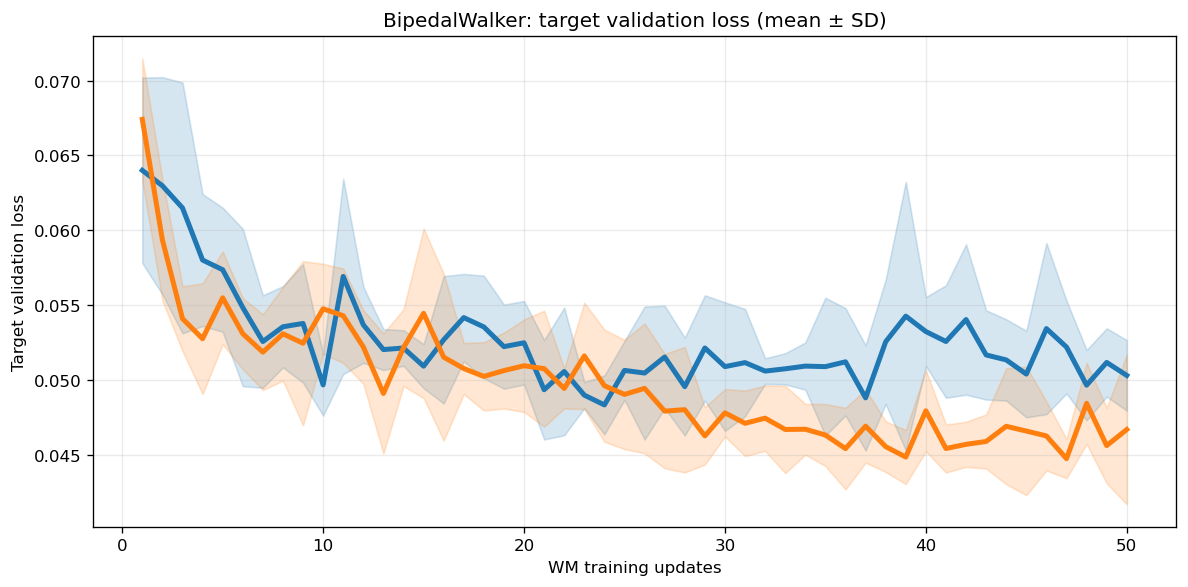

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in frames.items():
    valid = df.dropna(subset=["Target_loss"])
    stats = valid.groupby("WM_updates")["Target_loss"].agg(["mean", "std", "count"])
    ax.fill_between(stats.index.to_numpy(),
                    (stats["mean"] - stats["std"]).to_numpy(),
                    (stats["mean"] + stats["std"]).to_numpy(),
                    color=COLORS[name], alpha=0.18)
    ax.plot(stats.index, stats["mean"], color=COLORS[name], linewidth=3, zorder=5)
    print(f"{name}: {valid.Seed.nunique()} seeds; n per update = {stats['count'].min()}–{stats['count'].max()}")
ax.set(title="BipedalWalker: target validation loss (mean ± SD)",
       xlabel="WM training updates", ylabel="Target validation loss")
fig.tight_layout()
plt.show()